# Exploratory Data Analysis on Earth Embeddings and Relevant Variables

## Variables include Elevation, Biome, Ecoregion, Temperature, Population Density,...

### Imports

In [1]:
import os
import sys
from pathlib import Path

In [2]:
import torch
import pandas as pd
import numpy as np

In [3]:
parent = Path.cwd().parent

### Load Data

SatCLIP embeddings

In [4]:
X = torch.load(str(parent / "s2100k-embeddings/satclip_embeddings.pt"))
X = X.numpy() # operations are on cpu

In [5]:
X

array([[-0.12198275, -0.10570826, -0.01822255, ..., -0.02585694,
        -0.05298701,  0.00239364],
       [-0.10403489,  0.01591932,  0.03106982, ...,  0.08658981,
         0.0763995 ,  0.0314091 ],
       [ 0.06508942, -0.01171703,  0.10875659, ..., -0.04767518,
        -0.02129544,  0.00310934],
       ...,
       [-0.02103681,  0.13627657,  0.01789123, ...,  0.0284341 ,
        -0.01903277, -0.01203714],
       [-0.1209112 , -0.01841773,  0.00394719, ..., -0.05035377,
        -0.11152306,  0.00350317],
       [-0.1332136 , -0.08349636,  0.07614457, ...,  0.00073868,
         0.01570184, -0.01015394]], shape=(69789, 256), dtype=float32)

Earth Engine Variables (from CSV with same indices as SatCLIP Embeddings)

In [6]:
df = pd.read_csv(str(parent/"text-descriptions/index_with_ee.csv"))

In [7]:
df

,fn,lat,lon,avg_evi,avg_ndvi,biome,country,ecoregion,elevation_m,nightlights,...,realm,soil_carbon_g_kg,soil_ph,state,temp_annual_C,temp_max_warmest_C,temp_min_coldest_C,temp_range_C,tree_cover_pct,land_cover
0,patch_1.tif,24.517396,51.253355,749.956522,848.782609,Deserts & Xeric Shrublands,Qatar,Arabian-Persian Gulf coastal plain desert,22.0,0.445833,...,Palearctic,0.0,8.3,Jarayan Al Batnah,27.400000,41.500000,12.900000,28.600000,0.0,Bare/Sparse Vegetation
1,patch_2.tif,42.969783,112.248149,992.913043,1298.173913,Deserts & Xeric Shrublands,China,Eastern Gobi desert steppe,1097.0,0.437500,...,Palearctic,0.0,8.1,Nei Mongol Zizhiqu,3.900000,28.799999,-23.299999,52.099998,0.0,Bare/Sparse Vegetation
2,patch_3.tif,-17.116714,19.013767,2899.130435,4440.217391,"Tropical & Subtropical Grasslands, Savannas & ...",Angola,Zambezian Baikiaea woodlands,1157.0,0.249167,...,Afrotropic,5.0,7.5,Cuando Cubango,22.200001,34.000000,6.300000,27.700001,3.0,Shrubland
3,patch_5.tif,41.529312,23.845330,2439.173913,4137.739130,Temperate Broadleaf & Mixed Forests,Bulgaria,Balkan mixed forests,469.0,0.455833,...,Palearctic,20.0,7.5,Blagoevgrad,12.000000,28.400000,-1.900000,30.299999,7.0,Cropland
4,patch_7.tif,27.616751,26.800696,901.260870,1115.478261,Deserts & Xeric Shrublands,Egypt,East Sahara Desert,121.0,0.385833,...,Palearctic,0.0,8.2,New Valley,21.299999,37.500000,3.900000,33.599998,0.0,Bare/Sparse Vegetation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69784,patch_99995.tif,-1.128649,125.110689,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69785,patch_99996.tif,80.721450,44.418605,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69786,patch_99997.tif,-73.608960,37.202655,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69787,patch_99998.tif,31.619386,60.960150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.columns.to_numpy()

array(['fn', 'lat', 'lon', 'avg_evi', 'avg_ndvi', 'biome', 'country',
       'ecoregion', 'elevation_m', 'nightlights', 'nnh', 'pop_density',
       'precip_annual_mm', 'precip_driest_mm', 'precip_wettest_mm',
       'realm', 'soil_carbon_g_kg', 'soil_ph', 'state', 'temp_annual_C',
       'temp_max_warmest_C', 'temp_min_coldest_C', 'temp_range_C',
       'tree_cover_pct', 'land_cover'], dtype=object)

Variable Processing from Dataframe

In [9]:
latlon_cols = ['lat', 'lon']

continuous_cols = [
    'avg_evi', 'avg_ndvi', 'elevation_m', 
    'nightlights', 'pop_density',
    'precip_annual_mm', 'precip_driest_mm', 'precip_wettest_mm',
    'soil_carbon_g_kg', 'soil_ph',
    'temp_annual_C', 'temp_max_warmest_C', 'temp_min_coldest_C',
    'temp_range_C', 'tree_cover_pct'
]

categorical_cols = ['biome', 'country', 'ecoregion', 'realm', 'state', 'land_cover', 'nnh']

drop_cols = ['fn']


In [10]:
print(df[continuous_cols].isnull().sum())
print(df[categorical_cols].isnull().sum())

avg_evi               11700
avg_ndvi              11700
elevation_m           11700
nightlights           11700
pop_density           11700
precip_annual_mm      11700
precip_driest_mm      11700
precip_wettest_mm     11700
soil_carbon_g_kg      11700
soil_ph               11700
temp_annual_C         11700
temp_max_warmest_C    11700
temp_min_coldest_C    11700
temp_range_C          11700
tree_cover_pct        11700
dtype: int64
biome         11724
country       11700
ecoregion     11700
realm         11724
state         11700
land_cover    11700
nnh           11724
dtype: int64


Drop rows with missing columns

In [11]:
original_index = df.index

df = df.dropna(subset=continuous_cols)
df = df.dropna(subset=categorical_cols)

keep_idx = df.index

X = X[keep_idx]


In [12]:
df

,fn,lat,lon,avg_evi,avg_ndvi,biome,country,ecoregion,elevation_m,nightlights,...,realm,soil_carbon_g_kg,soil_ph,state,temp_annual_C,temp_max_warmest_C,temp_min_coldest_C,temp_range_C,tree_cover_pct,land_cover
0,patch_1.tif,24.517396,51.253355,749.956522,848.782609,Deserts & Xeric Shrublands,Qatar,Arabian-Persian Gulf coastal plain desert,22.0,0.445833,...,Palearctic,0.0,8.3,Jarayan Al Batnah,27.400000,41.500000,12.900000,28.600000,0.0,Bare/Sparse Vegetation
1,patch_2.tif,42.969783,112.248149,992.913043,1298.173913,Deserts & Xeric Shrublands,China,Eastern Gobi desert steppe,1097.0,0.437500,...,Palearctic,0.0,8.1,Nei Mongol Zizhiqu,3.900000,28.799999,-23.299999,52.099998,0.0,Bare/Sparse Vegetation
2,patch_3.tif,-17.116714,19.013767,2899.130435,4440.217391,"Tropical & Subtropical Grasslands, Savannas & ...",Angola,Zambezian Baikiaea woodlands,1157.0,0.249167,...,Afrotropic,5.0,7.5,Cuando Cubango,22.200001,34.000000,6.300000,27.700001,3.0,Shrubland
3,patch_5.tif,41.529312,23.845330,2439.173913,4137.739130,Temperate Broadleaf & Mixed Forests,Bulgaria,Balkan mixed forests,469.0,0.455833,...,Palearctic,20.0,7.5,Blagoevgrad,12.000000,28.400000,-1.900000,30.299999,7.0,Cropland
4,patch_7.tif,27.616751,26.800696,901.260870,1115.478261,Deserts & Xeric Shrublands,Egypt,East Sahara Desert,121.0,0.385833,...,Palearctic,0.0,8.2,New Valley,21.299999,37.500000,3.900000,33.599998,0.0,Bare/Sparse Vegetation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69584,patch_99791.tif,-28.881791,120.951277,863.086957,1757.260870,Deserts & Xeric Shrublands,Australia,Western Australian Mulga shrublands,392.0,0.284167,...,Australasia,5.0,7.2,Western Australia,20.000000,35.500000,5.700000,29.799999,2.0,Shrubland
69585,patch_99792.tif,-25.394124,22.642093,1567.826087,2737.782609,Deserts & Xeric Shrublands,Botswana,Kalahari xeric savanna,1019.0,0.478333,...,Afrotropic,5.0,7.1,Kgalagadi,20.000000,34.400002,1.800000,32.599998,0.0,Shrubland
69586,patch_99795.tif,57.256255,96.340135,3176.260870,5863.913043,Boreal Forests/Taiga,Russia,East Siberian taiga,278.0,0.561667,...,Palearctic,95.0,5.2,Krasnoyarskiy Kray,-1.700000,24.600000,-27.799999,52.400002,56.0,Tree cover
69587,patch_99796.tif,40.015116,94.781452,410.956522,590.956522,Deserts & Xeric Shrublands,China,Alashan Plateau semi-desert,1550.0,0.458333,...,Palearctic,0.0,7.9,Gansu Sheng,7.800000,30.500000,-16.500000,47.000000,0.0,Bare/Sparse Vegetation


### Some basic statistics

In [13]:
print(f"Means: \n\n{df[continuous_cols].mean()}")
print(f"\n\nMedians: \n\n{df[continuous_cols].median()}")

Means: 

avg_evi               1985.319101
avg_ndvi              3300.522405
elevation_m            710.579110
nightlights              0.733771
pop_density             46.949747
precip_annual_mm       561.300353
precip_driest_mm        11.267080
precip_wettest_mm      106.992577
soil_carbon_g_kg        22.485232
soil_ph                  6.998033
temp_annual_C           16.832700
temp_max_warmest_C      32.620685
temp_min_coldest_C       0.633648
temp_range_C            31.987037
tree_cover_pct          11.131973
dtype: float64


Medians: 

avg_evi               1642.739130
avg_ndvi              2881.260870
elevation_m            439.000000
nightlights              0.386667
pop_density              1.811839
precip_annual_mm       398.000000
precip_driest_mm         3.000000
precip_wettest_mm       75.000000
soil_carbon_g_kg        10.000000
soil_ph                  7.400000
temp_annual_C           20.000000
temp_max_warmest_C      33.200001
temp_min_coldest_C       4.500000
temp_range_

### Continuous Variables
(Focus on these for now)

Note: There are ways to implement this for categorical variables, but standard practice is doing a one-hot encoding. In practice, an issue arises when we have a high cardinality of categories (like country [185], state [2102], or even ecoregions [701] in our case). If we do this on enough samples (on the order of 70,000 which we have with S2-100k), we should be fine. However, we run into issues when we have fewer samples, where the resulting matrix has almost as many columns as observations, leading to overfitting. Other ways to combat this involve label encoding, and target encoding...

In [14]:
Y = df[continuous_cols].values
Y

array([[ 7.49956522e+02,  8.48782609e+02,  2.20000000e+01, ...,
         1.28999996e+01,  2.86000004e+01,  0.00000000e+00],
       [ 9.92913043e+02,  1.29817391e+03,  1.09700000e+03, ...,
        -2.32999992e+01,  5.20999985e+01,  0.00000000e+00],
       [ 2.89913043e+03,  4.44021739e+03,  1.15700000e+03, ...,
         6.30000019e+00,  2.77000008e+01,  3.00000000e+00],
       ...,
       [ 3.17626087e+03,  5.86391304e+03,  2.78000000e+02, ...,
        -2.77999992e+01,  5.24000015e+01,  5.60000000e+01],
       [ 4.10956522e+02,  5.90956522e+02,  1.55000000e+03, ...,
        -1.65000000e+01,  4.70000000e+01,  0.00000000e+00],
       [ 7.01478261e+02,  1.92217391e+03,  1.90000000e+01, ...,
        -2.91000004e+01,  4.19000015e+01,  6.00000000e+00]],
      shape=(58065, 15))

#### Standardize

In [15]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
Y_scaled = scaler_Y.fit_transform(Y)


### CCA (Canonical Correlation Analysis)

In [16]:
from sklearn.cross_decomposition import CCA

In [17]:
n_components = min(10, Y.shape[1]) # just to try for now

cca = CCA(n_components=n_components)
X_c, Y_c = cca.fit_transform(X_scaled, Y_scaled)


KeyboardInterrupt: 

In [ ]:
corrs = [
    np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1]
    for i in range(n_components)
]

for i, c in enumerate(corrs):
    print(f"Component {i+1}: {c:.3f}")


Component 1: 0.079
Component 2: 0.077
Component 3: 0.074
Component 4: 0.073
Component 5: 0.072
Component 6: 0.070
Component 7: 0.067
Component 8: 0.066
Component 9: 0.064
Component 10: 0.062


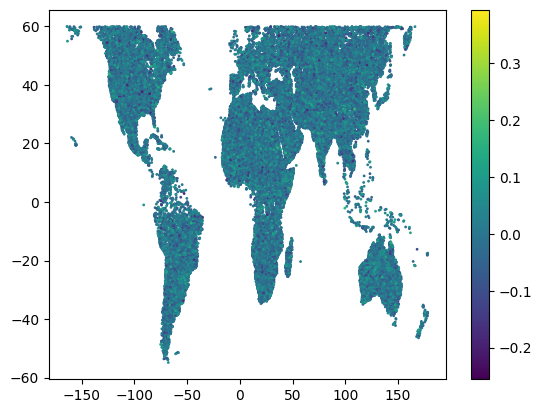

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(df['lon'], df['lat'], c=X_c[:,0], s=1, cmap='viridis')
plt.colorbar()